In [1]:
# Recharchement automatique des modules src/ à chaque modification
%load_ext autoreload
%autoreload 2

# Ajout de la racine du projet au path Python pour accéder à config et src/
import sys
sys.path.append('..')

# Importation de la configiguration (chemins, constantes)
import config

# Importation des modules du projets
from src import data_loader, data_quality, data_preprocessing, eda, features_engineering, models, evaluation, interpretability

import pandas as pd

## 1. Chargement des données

In [2]:
# Chargement du dataset depuis le chemin définis dans la config
# La fonction valide si le téléchargement a réussi et affiche un résumé
df = data_loader.data_loading(config.data_path)

Téléchargement réussi - 1338 lignes, 7 colonnes


Le dataset contient 1337 assurés et 7 variables : <br>
- 3 variables numériques : `age`, `bmi`, `children` <br>
- 3 variables catégorielles : `sex`, `smoker`, `region` <br>
- La variable cible : `charges` (coûts médicaux en dollars) <br>

## 2. Test de qualité des données : 
Valeurs manquantes, types de variables, doublons, valeurs aberrantes

In [3]:
# Contrôle 1 - valeur manquantes - nombre de valeurs manquantes et pourcentage de valeurs manquantes par colonne
data_quality.check_missing_values(df)

# Contrôle 2 - types de variables : comparaison avec les types attendus, définis dans config
data_quality.check_dtypes(df)

# Contrôle 3 - doublons 
data_quality.check_duplicates(df)

# Contrôle 4 - outliers : détection de valeur via la méthode des IQR
data_quality.check_outliers(df)

Aucune valeurs manquantes
Tous les types sont conformes
1 doublons détectés
charges : 6 outlier(s) | seuil bas = -30958.59 | seuil haut = 52338.79


Bilan des tests de qualité : 
- Aucune valeur manquante
- Tous les types sont conformes
- 1 doublon détecté
- 6 outliers détectés sur charges

Le seuil IQR a été fixé à 3× (au lieu de 1.5× conventionnel) car la distribution de charges est fortement asymétrique à droite. <br>
Un seuil à 1.5× surclassifierait des sinistres élevés mais légitimes.

## 3. Correction des anomalies

In [4]:
# # Suppression du doublon détecté et flagging des outliers sur charges
df = data_preprocessing.fix_data(df)

Doublons supprimés : 1 ligne(s) retirée(s)
Outliers flaggés : 6 ligne(s) marquée(s) dans 'is_outlier'


Les 6 outliers sont conservés et marqués dans la colonne `is_outlier` — en actuariat, les sinistres extrêmes sont des données légitimes et précieuses pour la modélisation.

## 4. EDA : analyse univariée, bivariée et multivariée

### 4.1 Analyse univariée

#### Distribution de la variable cible

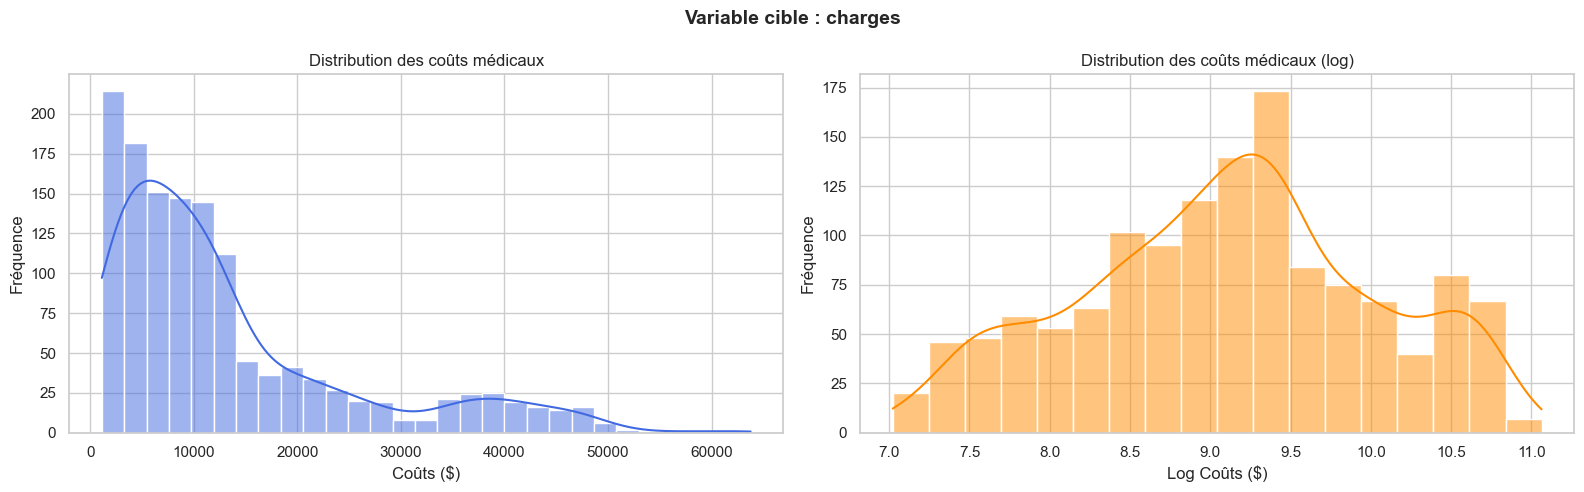

In [5]:
# Distribution de la variable cible charges en échelle normale et logarithmique
eda.plot_target_distributions(df, 'charges')

La distribution de charges est fortement asymétrique à droite : la majorité des assurés coûtent peu, mais quelques sinistres tirent la moyenne vers le haut. <br>
Après transformation logarithmique, la distribution se rapproche d'une gaussienne, ce qui justifie l'utilisation d'un lien log dans les GLM actuariels.

#### Distribution des variables numériques

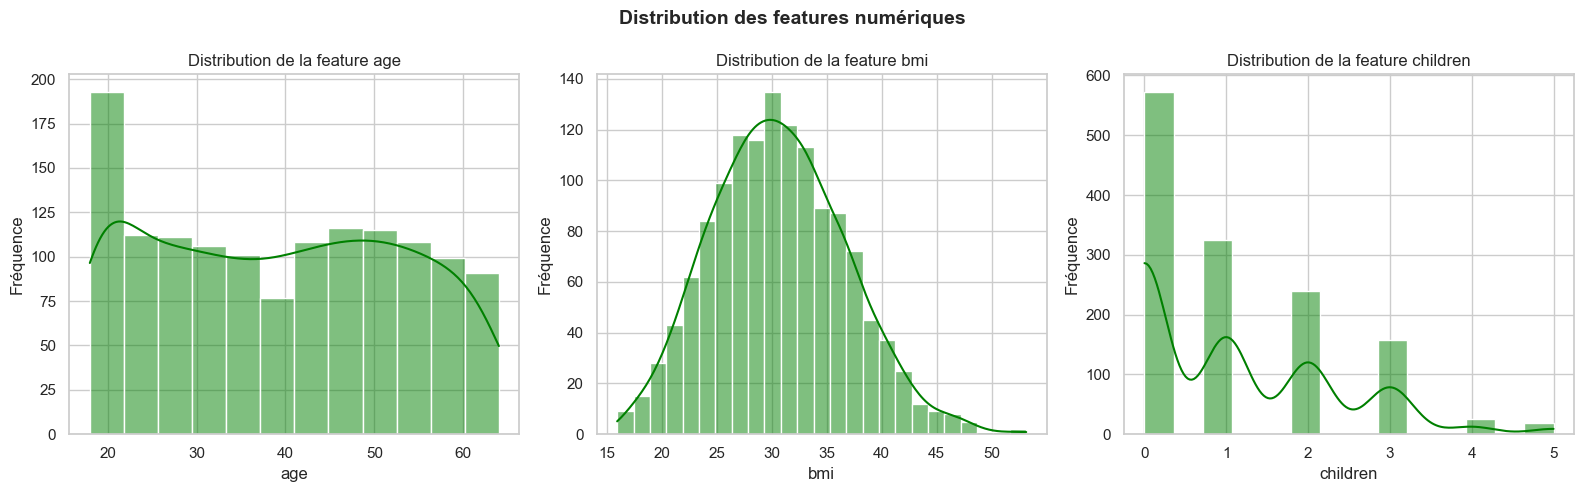

In [6]:
# Distribution des variables numériques : age, bmi et children
eda.plot_numerical_features(df, ['age', 'bmi', 'children'])

- `age` : distribution quasi-uniforme, avec unn pic aux alentours de 20 ans mais suggère que notre portefeuille couvre toute les tranches d'âges de manière équilibrée
- `bmi` : distribution symétrique centrée autour de 30 - seuil d'obésité, une partie significative du portefeuille semble en surpoids
- `children` : la majorité des assurés ont peu d'enfants (ou pas d'enfant), les familles nombreuses sont rares

#### Distribution des variables catégorielles

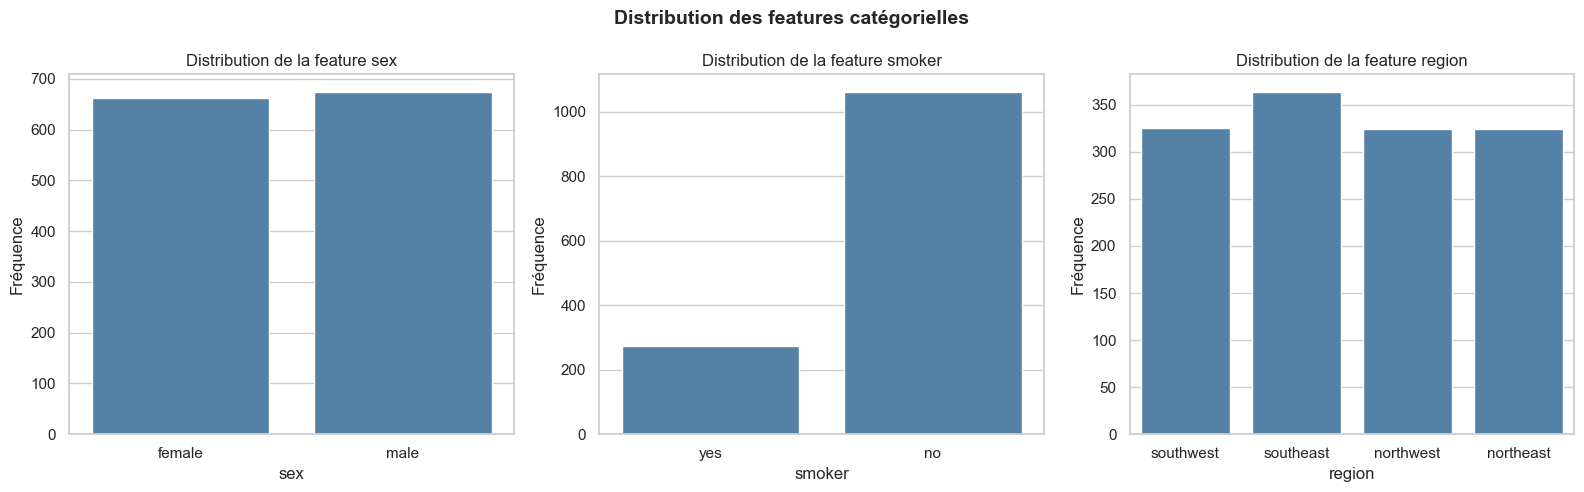

In [7]:
# Distribution des variables catégorielles : sex, smoker et region
eda.plot_categorial_features(df, ['sex', 'smoker', 'region'])

- `sex` : le portefeuille est équilibré entre homme et femmes
- `smoker` : minorité de fumeur mais driver dominant du risque comme nous le verront dans l'analyse bivariée
- `region` : répartition homogène entre les 4 régions

#### Statistiques descriptives du portefeuille

In [8]:
# Statistiques descriptive du portefeuille : 
# variable numériques : moyenne, médiane, min/max
# variable catégorielles : proportions par catégorie
# variable cible : coût moyen global et par catégorie
eda.print_summary_stats(df)

STATISTIQUES DESCRIPTIVES DU PORTEFEUILLE

VARIABLES NUMÉRIQUES
Age moyen        : 39.2 ans
Age médian       : 39.0 ans
Age min / max    : 18 / 64 ans
BMI moyen        : 30.7
Nb enfants moyen : 1.1

VARIABLES CATÉGORIELLES
Proportion fumeurs  : 20.5%
Proportion femmes   : 49.5%

Répartition par région :
region
southeast    27.2
southwest    24.3
northwest    24.2
northeast    24.2

VARIABLE CIBLE : CHARGES
Coût moyen global         : 13,279$
Coût médian global        : 9,386$

Coût moyen fumeurs        : 32,050$
Coût moyen non-fumeurs    : 8,441$

Coût moyen par région :
region
northeast    13,406$
northwest    12,451$
southeast    14,735$
southwest    12,347$



Le coût moyen des fumeurs est environ 3x supérieur à celui des non-fumeurs. <br>
Cette différence massive confirme que le statut fumeur est le facteur de risque dominant du portefeuille.

### 4.2 Analyse bivariée

#### Charges vs variables numériques

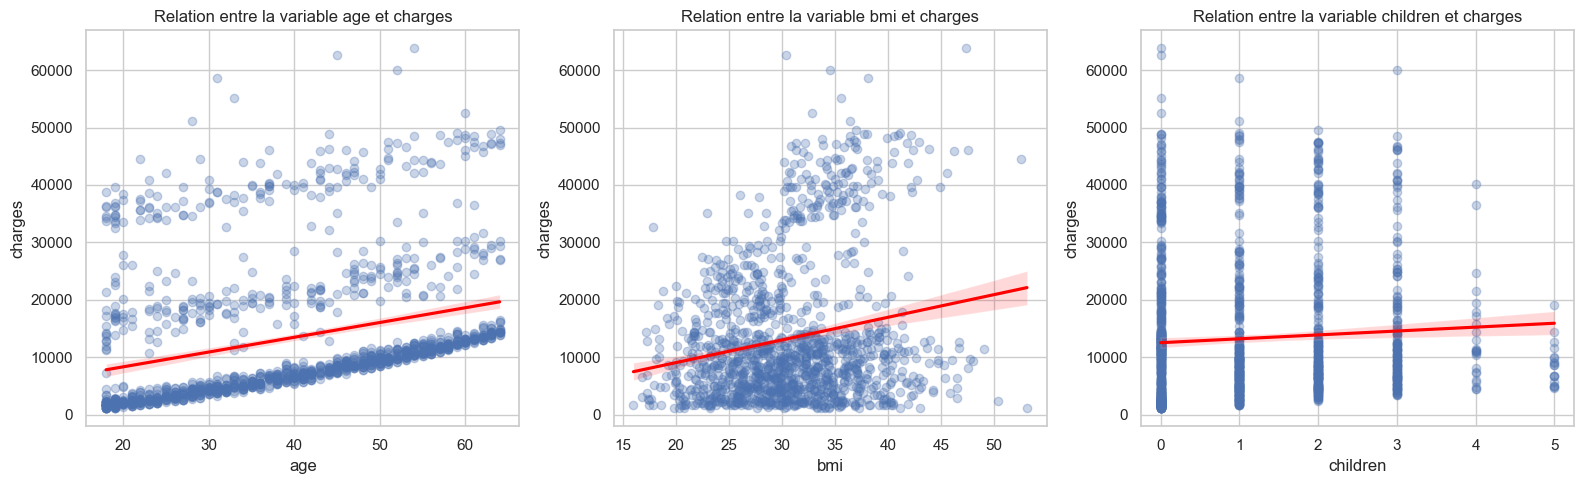

In [9]:
# Relation entre charges et chaque variable numérique via regplot
eda.plot_target_vs_num(df, col_target='charges', col_num=['age', 'bmi', 'children'])

- `age` : relation linéaire positive, les charges augmentent avec l'âge, mais on observe deux nuages de points distincts suggérant une segmentation cachée (fumeurs vs non-fumeurs)
- `bmi` : relation positive, on distingue également deux voir trois clusters : l'effet du BMI semble conditionnel au statut fumeur
- `children` : relation quasi nulle

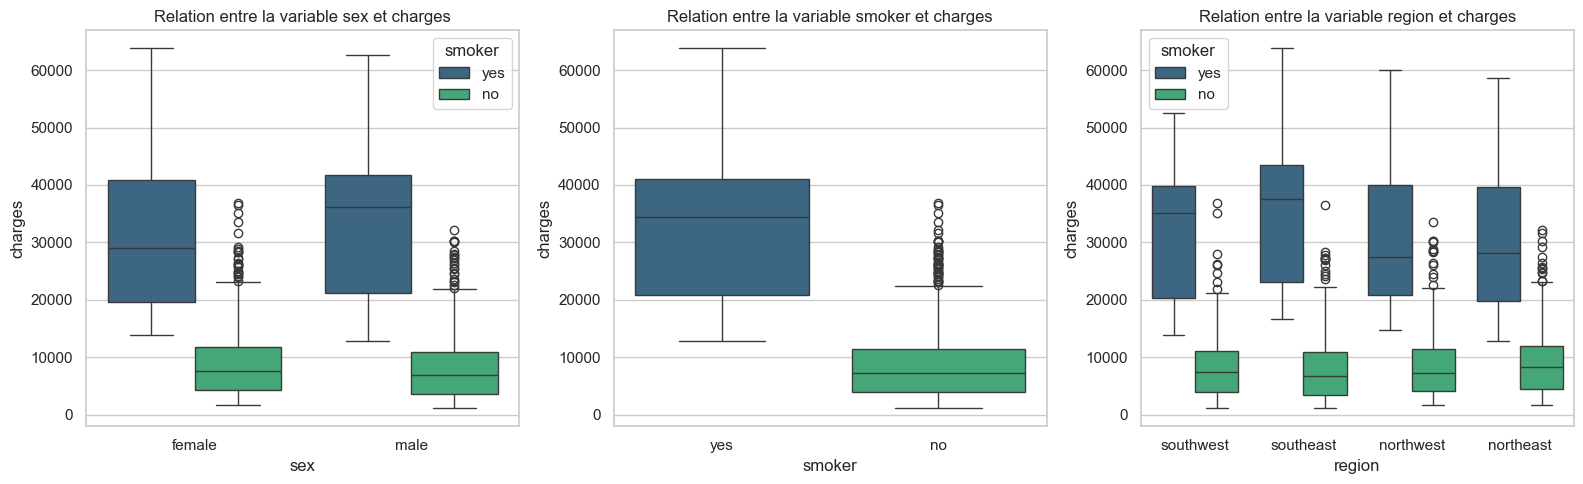

In [10]:
# Relation entre charges et chaque variable catégorielles via boxplot
eda.plot_target_vs_cat(df, col_target='charges', col_cat=['sex', 'smoker', 'region'])

- `sex` : distribution des charges quasi identique entre hommes et femmes
- `smoker` : écart massif entre fumeurs et non-fumeurs, les fumeurs ont une médiane de charges 3x supérieure avec une dispersion bien plus grande. 
- `region` :  distributions homogènes entre les 4 régions

Dans chaque graphique, la segmentation par `smoker` révèle que l'effet fumeur domine toutes les autres variables catégorielles.

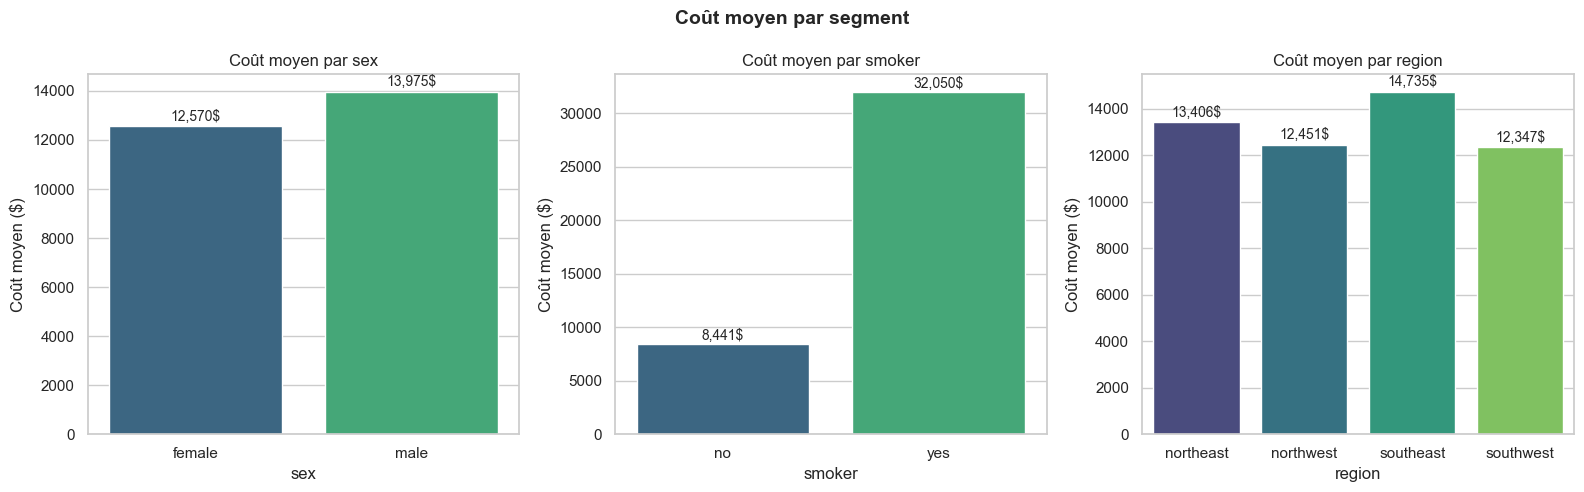

In [11]:
# Coût moyen par segment pour chaque variable catégorielle
eda.plot_means_charges_by_cat(df=df,col_target='charges', col_cat=['sex', 'smoker', 'region'])

Le barplot confirme quantitativement les observations précédentes :
- `smoker` : les fumeurs coûtent en moyenne ~32 000$ contre ~8 000$ pour les non-fumeurs — un ratio de 4x qui justifie pleinement une segmentation tarifaire sur ce critère
- `region` : les écarts entre régions sont faibles (~1 000$ d'écart max)
- `sex` : écart négligeable entre hommes et femmes

#### Tests statistiques 

In [12]:
eda.run_statistical_tests(df=df,col_target='charges', col_num=['age', 'bmi', 'children'],col_cat=['sex', 'smoker', 'region'])


TESTS STATISTIQUES — RELATION AVEC CHARGES
------------------------------------------------------------
variable    test  statistique  p_value significatif
     age Pearson       0.2983   0.0000          Oui
     bmi Pearson       0.1984   0.0000          Oui
children Pearson       0.0674   0.0137          Oui
     sex   ANOVA       4.5130   0.0338          Oui
  smoker   ANOVA    2175.7369   0.0000          Oui
  region   ANOVA       2.9261   0.0328          Oui
------------------------------------------------------------
Seuil de significativité : p-value < 0.05


Tous les tests sont significatifs (p-value < 0.05), toutes les variables ont un effet statistiquement prouvé sur la variable cible et seront toutes conservées pour la modélisation.

Parmi les variables numériques : 
- L'âge a une corrélation plutôt faible avec charges (0,29) mais plus l'âge augmente plus les charges ont tendance à augmenter
- Le BMI a une corrélation très faible (0.19)
- Le nombre de d'enfant a une corrélation quasi nulle (0.06) suggérant que le nombre d'enfants n'est pas un facteur de risque important

Parmi les variables catégorielles :<br>
La variable smoker est de loin le facteur de risque le plus important avec une F-statistique de 2175, soit environ 500 fois supérieure à celle de region (3) et sex (4).

Dans la modélisation nous étudierons également l'interraction entre la variable BMI et smoker. <br>
L'hypothèse étant que l'effet de l'indice de masse corporel est conditionnel au statut fumeur, un fumeur ayant un BMI élevé génèrera un surcoût supérieur à la somme des deux effets pris séparement.


### 4.3 Analyse multivariée

#### Pairplot - segmentation par statut fumeur

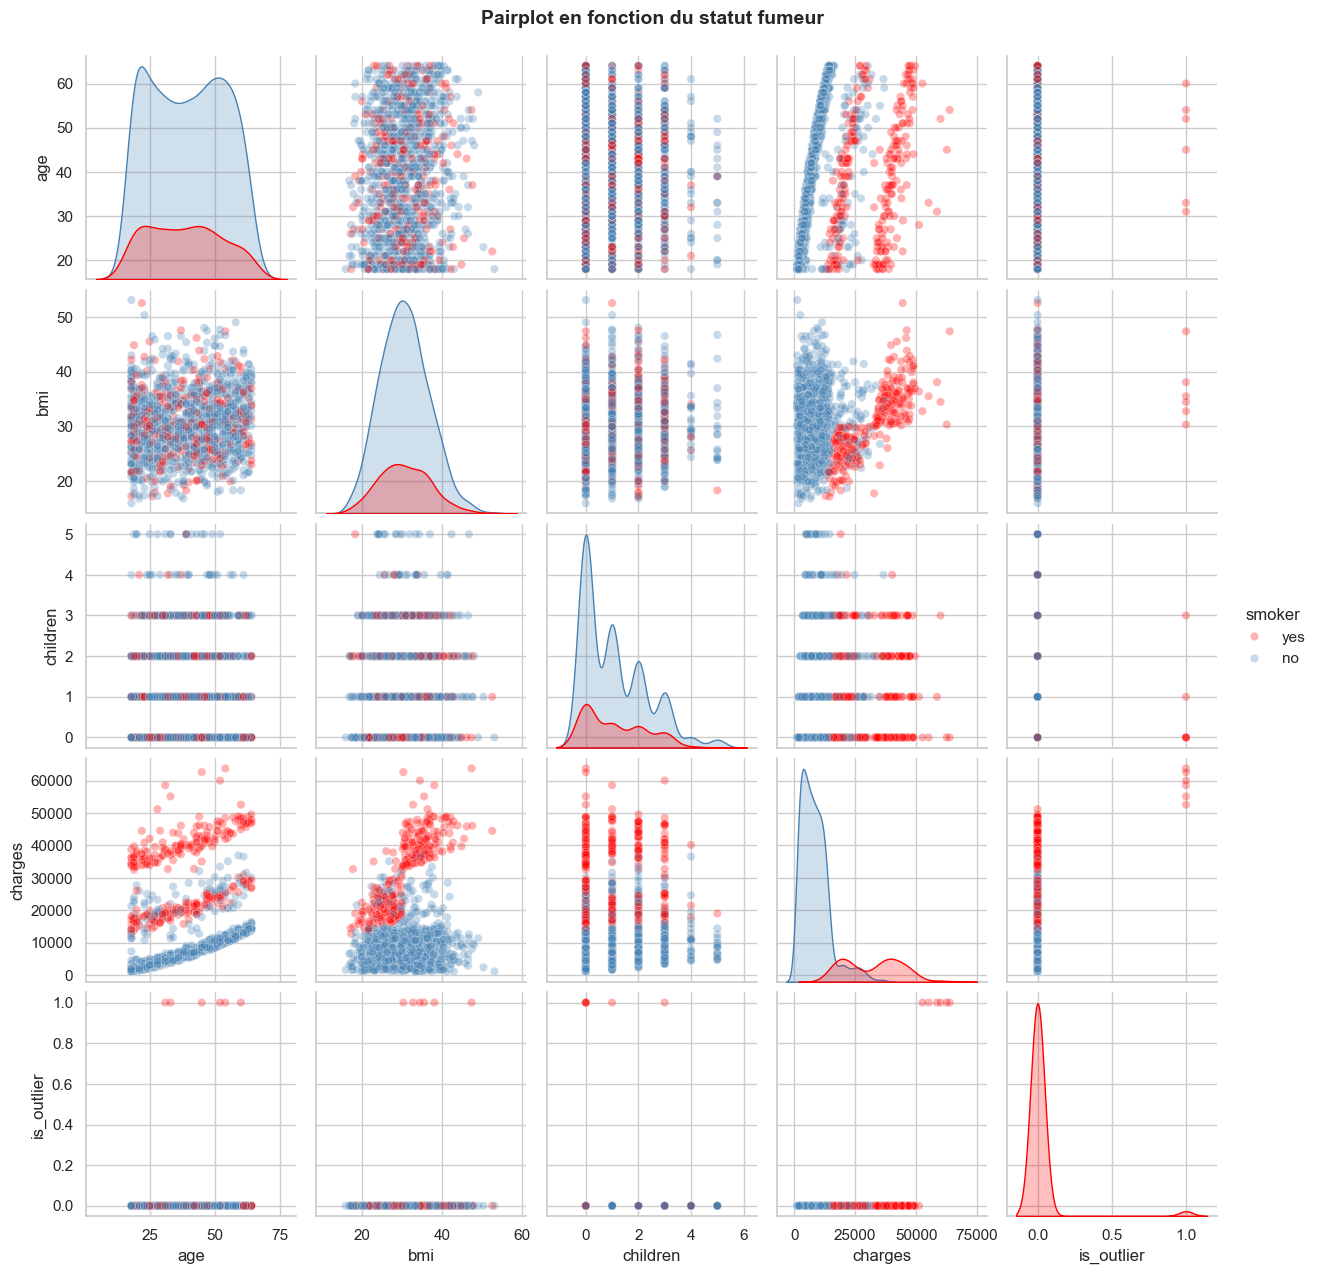

In [13]:
# Pairplot - segmentation par statut fumeur
eda.plot_pairplot(df)

Le pairplot révèle une segmentation nette du portefeuille en deux populations :
- Les non-fumeurs (bleu) forment un nuage compact avec des charges modérées
- Les fumeurs (rouge) se distinguent clairement avec des charges bien plus élevées et dispersées
- La combinaison bmi x charges montre deux clusters distincts, c'est une confirmation visuelle qu'il y a bien une interraction entre smoker et bmi.
-  Les variables `age` et `bmi` ont des distributions similaires entre fumeurs et non-fumeurs, le tabagisme est indépendant de l'âge et du poids dans ce portefeuille

## 5. Features engineering
Création de 3 nouvelles variables : 
- `obese` : indicateur d'obésité (BMI > 30)
- `age_group` : segmentation en tranches d'âge
- `obese_smoker` : interaction fumeur & obèse

In [14]:
# Création de features
df = features_engineering.create_features(df=df)

## 6 . Preprocessing

### 6.1 Encodage des variables catégorielles

In [15]:
# Encodage des variables catégorielle pour la modélisation
df_encoded = data_preprocessing.encode_data(df=df)

### 6.2 Transformation de la variable cible

In [16]:
# Transformation logarithmique de la variable charges
# log_charges sera utilisée comme target pour les modèles linéaires (LR, Lasso)
# charges brut sera conservé pour les GLM et les modèles ensemblistes
df_encoded = features_engineering.log_charges(df_encoded)

La transformation log crée une colonne `log_charges` tout en gardant `charges`, les deux versions sont conservées pour comparer les modèles sur la même échelle (dollars) après back-transformation exponentielle des prédictions log.

### 6.3 Matrice de corrélation

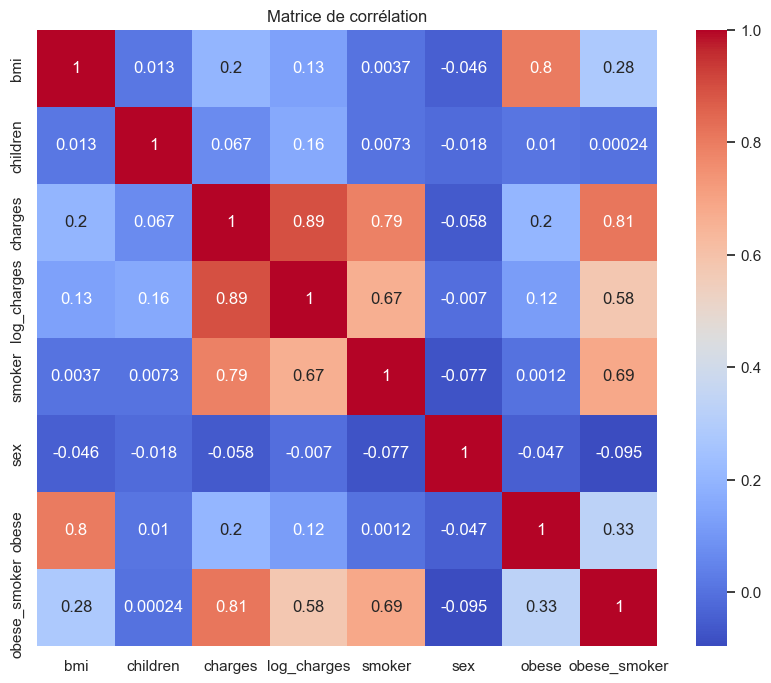

In [17]:
# Matrice de corrélation sur les variables numériques du dataset encodé
eda.plot_correlation_matrix(df_encoded)

- `smoker` présente la corrélation la plus forte avec `charges`, confirme son statut de risque dominant
- `obese_smoker` est fortement corrélé avec `charges`, valide la pertinence de cette variable d'interaction
- `obese` seul est faiblement corrélé avec `charges`, l'effet de l'obésité passe presque entièrement par l'interaction avec `smoker`
- Pas de multicolinéarité problématique entre les features, le modèle ne sera pas instabilisé

### 6.4 Split train / test

In [18]:
# Sépération en échantillon de train et test avec stratifié sur smoker
# La stratification garantit que la proportion de fumeurs (~20%) est identique dans le train et le test
X_train, X_test, y_train, y_test = data_preprocessing.split_data(df = df_encoded, col_target='log_charges', col_stratify=df_encoded['smoker'])

La taille du jeu d'entraînement est de : (1069, 18)
La taille du jeu de test est de : (268, 18)


In [ ]:
# Liste de stockage des métriques d'évaluation
# Alimenté à chaque appel de evaluation.store_and_display()
# Permet d'afficher un tableau comparatif mis à jour après chaque modèle
results = [] 

## 7. Modélisation et évaluation
On compare 7 modèles sur la même échelle (dollars) pour identifier le plus performant.

### 7.1 Régression Linéaire (baseline)

Régression linéaire entrainée
Régression linéaire
Score R² : 0.4977
MAE : 3866.2774
RMSE : 8509.5593


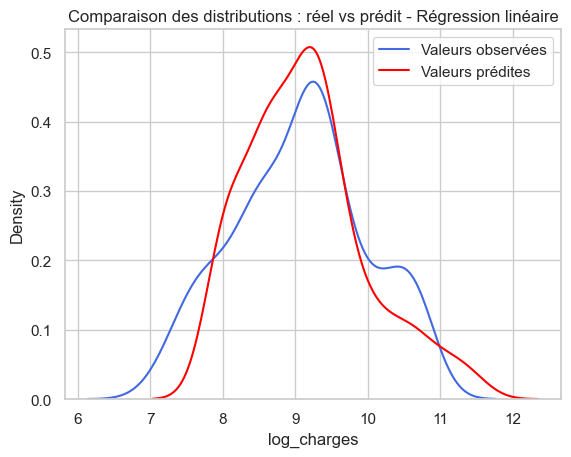

1 modèle(s) enregistré(s)


,modèle,R²,MAE ($),RMSE ($)
0,Régression linéaire,0.4977,3866.28,8509.56


In [ ]:
# Entraînement de la régression linéaire via pipeline (StandardScaler + LinearRegression)
pipeline_lr = models.linear_regression(X_train, y_train)

# Évaluation sur le test set
metrics_lr = evaluation.evaluate_model(pipeline = pipeline_lr, X_test = X_test, y_test = y_test, model_name="Régression linéaire", log_target =True)

# Visualisation de la distribution observé vs prédit
evaluation.plot_prediction(pipeline=pipeline_lr, X_test=X_test, y_test=y_test, model_name="Régression linéaire")

# Stockage des métriques et affichage du tableau comparatif mis à jour
evaluation.store_and_display(results=results, metrics=metrics_lr)

Les performances sont moyennes. Le modèle explique moins de 50% de la variance des coûts médicaux. <br>
L'erreur moyenne de 3866$ est élevée, le modèle linéaire ne capture pas les non-linéarités du dataset, notamment l'effet combiné `smoker × bmi`. <br>
Le RMSE élevé à 8509$ indique des erreurs importantes sur les sinistres extrêmes.

### 7.2 Régression LASSO

Régression LASSO entrainée
Régression LASSO
Score R² : 0.5050
MAE : 3843.8391
RMSE : 8447.3435


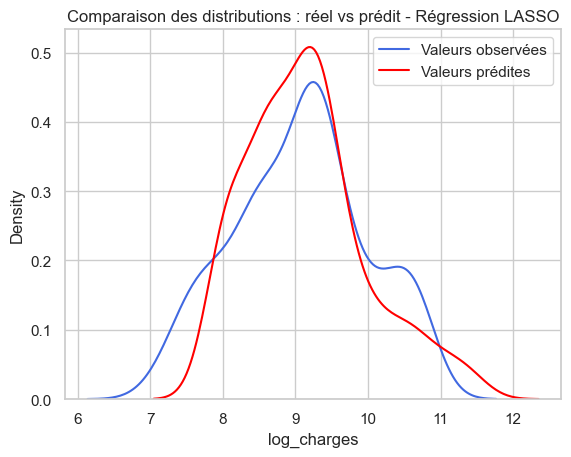

2 modèle(s) enregistré(s)


,modèle,R²,MAE ($),RMSE ($)
0,Régression LASSO,0.5050,3843.84,8447.34
1,Régression linéaire,0.4977,3866.28,8509.56


In [ ]:
# Entraînement du Lasso via pipeline (StandardScaler + LassoCV)
pipeline_lasso = models.lasso_regression(X_train, y_train)

# Évaluation sur le test set
metrics_lasso = evaluation.evaluate_model(pipeline = pipeline_lasso, X_test = X_test, y_test = y_test, model_name="Régression LASSO", log_target =True)

# Visualisation de la distribution observé vs prédit
evaluation.plot_prediction(pipeline=pipeline_lasso, X_test=X_test, y_test=y_test, model_name="Régression LASSO")

# Stockage des métriques et affichage du tableau comparatif mis à jour
evaluation.store_and_display(results=results, metrics=metrics_lasso)

Le Lasso n'apporte pas d'amélioration significative par rapport à la régression linéaire, les métriques sont quasi identiques. <br>
Cela suggère que la régularisation n'est pas nécessaire ici, les features sont déjà peu nombreuses et non redondantes. <br>
Le Lasso confirme néanmoins que toutes les variables contribuent au modèle puisqu'aucun coefficient n'a été forcé à zéro

### 7.3 Modèles actuariels
#### Nouveau split — target = `charges`
Les GLM (Gamma, Tweedie) et modèles ensemblistes (Random Forest, XGBoost) modélisent directement `charges` en dollars <br>
On crée un split dédié pour ces modèles.

In [22]:
# Nouveau split avec charges comme target (et non log_charges)
# Les GLM et modèles ensemblistes modélisent directement charges en dollars
X_train_glm, X_test_glm, y_train_glm, y_test_glm = data_preprocessing.split_data(df = df_encoded, col_target='charges', col_stratify=df_encoded['smoker'])

La taille du jeu d'entraînement est de : (1069, 18)
La taille du jeu de test est de : (268, 18)


#### GLM Tweedie (power=1.5)

Régression GLM Tweedie entrainée
Régression GLM Tweedie
Score R² : 0.7626
MAE : 3367.0136
RMSE : 5849.4271


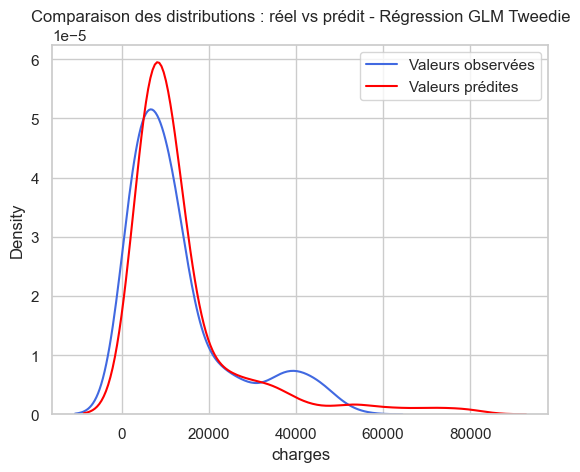

3 modèle(s) enregistré(s)


,modèle,R²,MAE ($),RMSE ($)
0,Régression GLM Tweedie,0.7626,3367.01,5849.43
1,Régression LASSO,0.5050,3843.84,8447.34
2,Régression linéaire,0.4977,3866.28,8509.56


In [ ]:
# Entraînement du GLM Tweedie (power=1.5, lien log)
# Modèle actuariel pour les coûts agrégés — adapté aux distributions asymétriques
pipeline_tweedie = models.glm_tweedie_regression(X_train_glm, y_train_glm)

# Évaluation sur le test set
metrics_tweedie = evaluation.evaluate_model(pipeline = pipeline_tweedie, X_test = X_test_glm, y_test = y_test_glm, model_name="Régression GLM Tweedie", log_target =False)

# Visualisation de la distribution observé vs prédit
evaluation.plot_prediction(pipeline=pipeline_tweedie, X_test=X_test_glm, y_test=y_test_glm, model_name="Régression GLM Tweedie")

# Stockage des métriques et affichage du tableau comparatif mis à jour
evaluation.store_and_display(results=results, metrics=metrics_tweedie)

Le GLM Tweedie surpasse largement les modèles linéaires avec un gain de +25 points de R².<br>
En modélisant directement charges avec une distribution adaptée aux coûts asymétriques, il surpasse largement la régression linéaire classique. <br>
Une erreur moyenne de 3367$ reste néanmoins significative — le modèle peine probablement sur les profils atypiques comme les grands fumeurs obèses.

#### GLM Gamma (power=2)

Régression GLM Gamma entrainée
Régression GLM Gamma
Score R² : 0.7118
MAE : 4619.5801
RMSE : 6445.1334


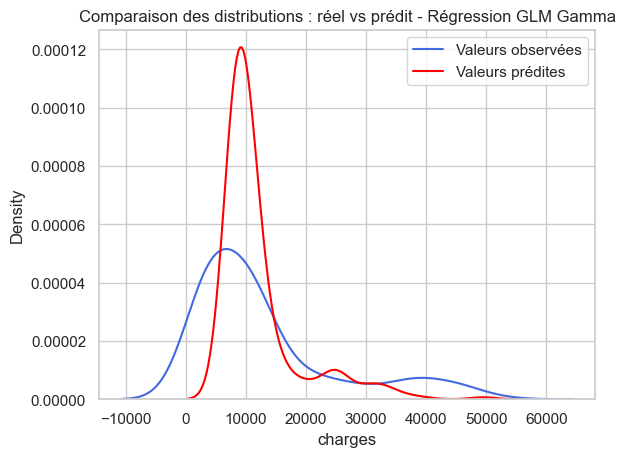

4 modèle(s) enregistré(s)


,modèle,R²,MAE ($),RMSE ($)
0,Régression GLM Tweedie,0.7626,3367.01,5849.43
1,Régression GLM Gamma,0.7118,4619.58,6445.13
2,Régression LASSO,0.5050,3843.84,8447.34
3,Régression linéaire,0.4977,3866.28,8509.56


In [ ]:
# Entraînement du GLM Gamma (power=2, lien log)
pipeline_gamma = models.glm_gamma_regression(X_train_glm, y_train_glm)

# Évaluation sur le test set
metrics_gamma = evaluation.evaluate_model(pipeline = pipeline_gamma, X_test = X_test_glm, y_test = y_test_glm, model_name="Régression GLM Gamma",log_target =False)

# Visualisation de la distribution observé vs prédit
evaluation.plot_prediction(pipeline=pipeline_gamma, X_test=X_test_glm, y_test=y_test_glm, model_name="Régression GLM Gamma")

# Stockage des métriques et affichage du tableau comparatif mis à jour
evaluation.store_and_display(results=results, metrics=metrics_gamma)

Le GLM Gamma, théoriquement plus adapté car charges ne contient aucun zéro, est paradoxalement moins performant que le Tweedie. <br>
Cela suggère que la structure des données se rapproche davantage d'un mélange fréquence-sévérité que d'un pur coût par sinistre. <br>
Le Tweedie (p=1.5) capture mieux cette nuance.

### 7.4 Modèles ensemblistes

#### Random Forest

Random Forest entrainé
Random Forest
Score R² : 0.8926
MAE : 2386.1016
RMSE : 3934.0085


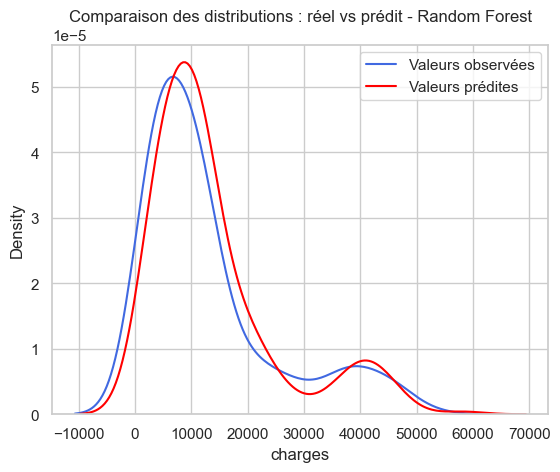

5 modèle(s) enregistré(s)


,modèle,R²,MAE ($),RMSE ($)
0,Random Forest,0.8926,2386.10,3934.01
1,Régression GLM Tweedie,0.7626,3367.01,5849.43
2,Régression GLM Gamma,0.7118,4619.58,6445.13
3,Régression LASSO,0.5050,3843.84,8447.34
4,Régression linéaire,0.4977,3866.28,8509.56


In [ ]:
# Entraînement du Random Forest (100 arbres, random_state=42)
pipeline_rf = models.random_forest(X_train_glm, y_train_glm)

# Évaluation sur le test set
metrics_rf = evaluation.evaluate_model(pipeline=pipeline_rf, X_test=X_test_glm, y_test=y_test_glm, model_name="Random Forest", log_target=False)

# Visualisation de la distribution observé vs prédit
evaluation.plot_prediction(pipeline=pipeline_rf, X_test=X_test_glm, y_test=y_test_glm, model_name="Random Forest")

# Stockage des métriques et affichage du tableau comparatif mis à jour
evaluation.store_and_display(results=results, metrics=metrics_rf)

Le Random Forest surpasse tous les modèles précédents avec un gain de +10 points de R² par rapport au GLM Tweedie. <br>
Sa capacité à capturer les non-linéarités et les interactions entre variables, notamment `smoker × bmi` explique cette amélioration significative.

#### XGBoost

XGBoost entrainé
XGBoost
Score R² : 0.9019
MAE : 2230.1072
RMSE : 3760.0713


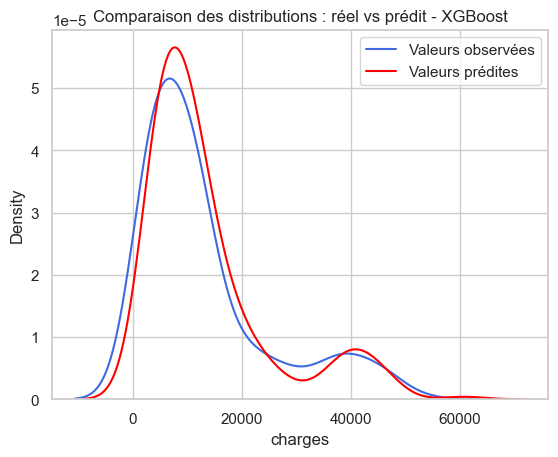

6 modèle(s) enregistré(s)


,modèle,R²,MAE ($),RMSE ($)
0,XGBoost,0.9019,2230.11,3760.07
1,Random Forest,0.8926,2386.10,3934.01
2,Régression GLM Tweedie,0.7626,3367.01,5849.43
3,Régression GLM Gamma,0.7118,4619.58,6445.13
4,Régression LASSO,0.5050,3843.84,8447.34
5,Régression linéaire,0.4977,3866.28,8509.56


In [ ]:
# Entraînement du XGBoost (100 arbres, learning_rate=0.1, random_state=42)
pipeline_xgb = models.xgboost(X_train_glm, y_train_glm)

# Évaluation sur le test set
metrics_xgb = evaluation.evaluate_model(pipeline=pipeline_xgb, X_test=X_test_glm, y_test=y_test_glm, model_name="XGBoost", log_target=False)

# Visualisation de la distribution observé vs prédit
evaluation.plot_prediction(pipeline=pipeline_xgb, X_test=X_test_glm, y_test=y_test_glm, model_name="XGBoost")

# Stockage des métriques et affichage du tableau comparatif mis à jour
evaluation.store_and_display(results=results, metrics=metrics_xgb)

XGBoost est le meilleur modèle avec un R² de 0.90 et une MAE de 2230$. <br>
Il surpasse le Random Forest grâce à son apprentissage par boosting, chaque arbre corrige les erreurs du précédent, ce qui le rend particulièrement efficace sur les interactions complexes comme smoker × bmi.

### 7. Optimisation du modèle XGBoost

In [27]:
# Optimisation des hyperparamètres XGBoost par GridSearchCV
pipeline_xgb_optimized = models.optimize_xgboost(X_train_glm, y_train_glm)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Meilleurs hyperparamètres : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
Meilleur R² (CV) : 0.8473


La recherche par GridSearch identifie la combinaison optimale d'hyperparamètres. <br>
Le meilleur R² en cross-validation (~0.84) est légèrement inférieur au score test (0.90), ce qui confirme que le modèle généralise bien sans overfitter.

XGBoost Optimisé
Score R² : 0.9153
MAE : 2117.4033
RMSE : 3494.2222


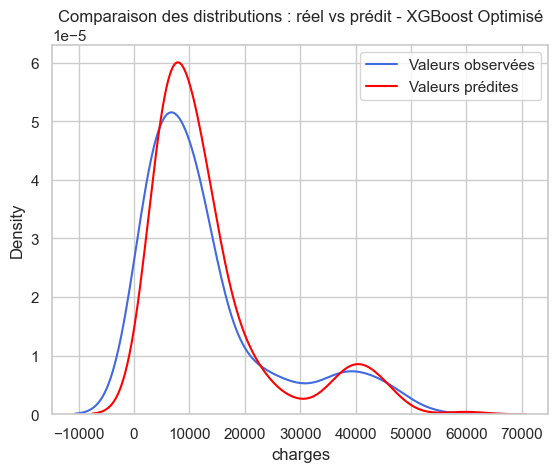

7 modèle(s) enregistré(s)


,modèle,R²,MAE ($),RMSE ($)
0,XGBoost Optimisé,0.9153,2117.40,3494.22
1,XGBoost,0.9019,2230.11,3760.07
2,Random Forest,0.8926,2386.10,3934.01
3,Régression GLM Tweedie,0.7626,3367.01,5849.43
4,Régression GLM Gamma,0.7118,4619.58,6445.13
5,Régression LASSO,0.5050,3843.84,8447.34
6,Régression linéaire,0.4977,3866.28,8509.56


In [ ]:
# Évaluation du XGBoost optimisé sur le test set
metrics_xgb_opt = evaluation.evaluate_model(pipeline=pipeline_xgb_optimized, X_test=X_test_glm, y_test=y_test_glm, model_name="XGBoost Optimisé", log_target=False)

# Visualisation de la distribution observé vs prédit
evaluation.plot_prediction(pipeline=pipeline_xgb_optimized, X_test=X_test_glm, y_test=y_test_glm, model_name="XGBoost Optimisé")

# Stockage et affichage du tableau comparatif final
evaluation.store_and_display(results=results, metrics=metrics_xgb_opt)

L'optimisation des hyperparamètres améliore les performances de +1.3 point de R² et réduit la MAE. <br>
Le modèle final explique 91,5% de la variance des coûts médicaux avec une erreur moyenne de 2117$

## 8. Interprétabilité du modèle

### 8.1 Importance globale des variables

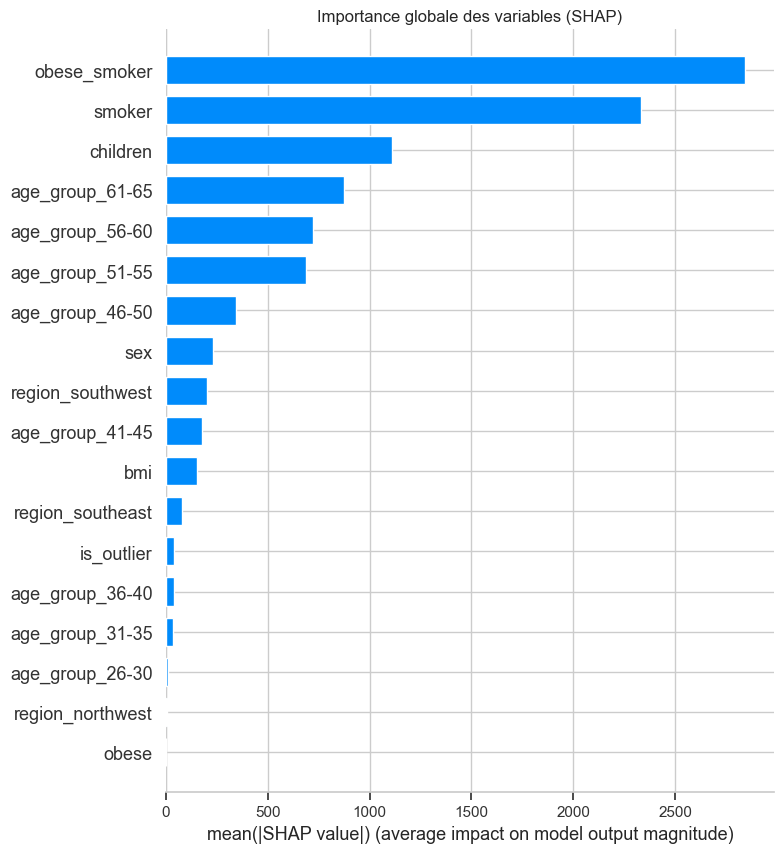

In [29]:
interpretability.shap_summary_plot(pipeline_xgb_optimized, X_test_glm)

Importance globale des variables <br>
Le graphique confirme et enrichit nos analyses précédentes :

- `obese_smoker` est la variable la plus importante (SHAP moyen ~2800$), notre feature engineering a bien capturé l'interaction entre l'obésité et le tabagisme. C'est la variable créée qui a le plus grand pouvoir prédictif.
- `smoker` arrive en deuxième position (~2400$), le statut fumeur seul reste un facteur majeur même en présence de l'interaction.
- Les tranches d'âge (51-55, 56-60, 61-65) apparaissent en 3ème, 4ème et 5ème position — les assurés âgés coûtent significativement plus cher
- `bmi` seul a un impact modéré (~200$) ce qui confirme notre hypothèse : c'est l'interaction avec  `smoker` qui compte, pas le BMI isolément
- `obese` seul est quasi nul — toute l'information est capturée par `obese_smoker`
- `region` et `sex` ont un impact très faible, cohérent avec nos tests statistiques

### 8.2 Explication individuelle — Waterfall Plot

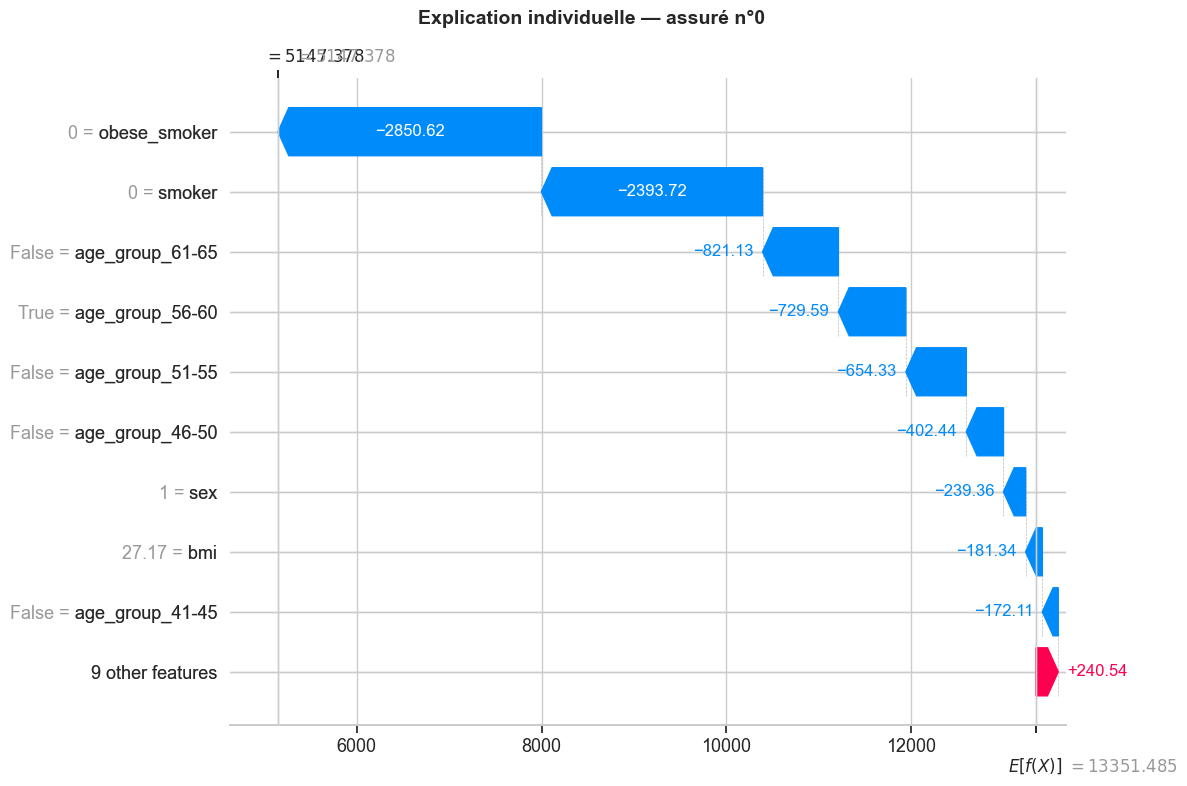

In [35]:
# SHAP Waterfall Plot — explication individuelle de la prédiction pour l'assuré n°0
# Montre la contribution de chaque variable à la prédiction finale
interpretability.shap_waterfall_plot(pipeline_xgb_optimized, X_test_glm, index=0)

Explication de la prédiction pour l'assuré n°0

Le modèle prédit **5 147$** de charges pour cet assuré, soit bien en dessous de la moyenne du portefeuille de **13 351$** (`E[f(X)]`).

Facteurs qui réduisent le coût prédit (barres bleues) :
- `obese_smoker = 0` = -2 851$ : l'assuré n'est ni fumeur ni obèse, forte réduction du risque
- `smoker = 0` = -2 394$ : confirmation du non-tabagisme
- Tranches d'âge 51-65 à `False` = -2 130$ au total, l'assuré n'est pas dans les tranches les plus coûteuses
- `bmi = 27.17` = -181$, BMI normal, pas d'obésité
- `sex = 1` = -239$, légère réduction liée au sexe

Facteur qui augmente le coût prédit (barre rouge) :
- `9 other features` = +241$, contribution positive résiduelle des autres variables

Conclusion : cet assuré est peu risqué car les deux facteurs de risque dominants du portefeuille : tabagisme et obésité sont absents. <br>
Ce type d'explication individuelle permet de justifier une prime auprès d'un assuré de façon transparente et chiffrée.

## 9. Sérialisation du modèle XGBoost optimisé

In [31]:
# Sauvegarde du modèle
models.save_model(pipeline_xgb_optimized, "xgboost_optimized.pkl")

# Chargement et vérification que les métriques sont identiques
# Simule le comportement en production — le modèle est chargé sans être réentraîné
pipeline_loaded = models.load_model("xgboost_optimized.pkl")
evaluation.evaluate_model(pipeline_loaded, X_test_glm, y_test_glm, "XGBoost Chargé", log_target=False)

Modèle sauvegardé : c:\Users\Léo\OneDrive\Desktop\medical_cost_pred_project\models\xgboost_optimized.pkl
Modèle chargé : c:\Users\Léo\OneDrive\Desktop\medical_cost_pred_project\models\xgboost_optimized.pkl
XGBoost Chargé
Score R² : 0.9153
MAE : 2117.4033
RMSE : 3494.2222


{'modèle': 'XGBoost Chargé',
 'R²': 0.9153,
 'MAE ($)': 2117.4,
 'RMSE ($)': 3494.22}

Le modèle chargé depuis le disque produit des métriques identiques au modèle original, la sérialisation est correcte.